# Calculate 2-point correlations as function of separation

We study **two-point correlation functions** of scalar fields on organoid surfaces.  
Each organoid is represented as a triangular mesh. Distances between vertices are computed using:

- **Heat method (Crane et al. 2013):** smooth geodesic approximation.  
- **Dijkstra (graph geodesic):** shortest path along mesh edges, used for comparison.  

To make correlations efficient:  
1. **Coarse-grain** vertices with farthest-point sampling.  
2. **Precompute distance bins** between vertex pairs.  
3. **Accumulate correlations per bin**, weighted by vertex areas.  

This yields normalized two-point functions of fields (e.g. HKS), revealing characteristic length scales of variation across the organoid surface.


In [18]:
from src.fatemarkers import FateMarkers

import matplotlib
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import glob
import os

from nonlocal_correlations import *

## Load organoid ensemble

In [19]:
data_dir = '../NicoleData/20250929/fractal_output'


timepoints = ['day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

# timepoints = ['day3p5', 'day4p5']

wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06'],
}

zarr_names = {tp: 'r0.zarr' for tp in timepoints}
rounds = {tp: '0_fused_zillum_registered' for tp in timepoints}
meshes = {tp: 'nnorg_linked_multi_annotated_class' for tp in timepoints}


In [20]:
def connected_and_normalized_correlations(Corr: np.ndarray, N: np.ndarray, X: np.ndarray):
    """
    Compute connected and normalized correlation functions.

    Args
    ----
    Corr : ndarray, shape (B, F, F)
        Raw correlation matrices per distance bin (output of accumulate_correlations_from_bins).
    N : ndarray, shape (B,)
        Normalization weights per distance bin (from accumulate_correlations_from_bins).
    X : ndarray, shape (V, F)
        Field values on vertices/cell centers (used to compute means and stds).

    Returns
    -------
    Corr_conn : ndarray, shape (B, F, F)
        Connected correlations: <F_i F_j> - <F_i><F_j>.
    Corr_norm : ndarray, shape (B, F, F)
        Connected + normalized correlations:
            ( <F_i F_j> - <F_i><F_j> ) / (\sigma_i \sigma_j).
    """
    F = Corr.shape[1]

    # --- global statistics for normalization ---
    means = np.mean(X, axis=0)       # (F,)
    vars_ = np.var(X, axis=0)        # (F,)
    stds = np.sqrt(vars_ + 1e-12)    # avoid div-by-zero

    # --- connected correlations ---
    Corr_conn = np.copy(Corr)
    for b in range(Corr.shape[0]):
        if N[b] > 0:
            Corr_conn[b] -= np.outer(means, means)
        else:
            Corr_conn[b] = np.full((F, F), np.nan)

    # --- normalized connected correlations ---
    Corr_norm = np.copy(Corr_conn)
    for b in range(Corr.shape[0]):
        if N[b] > 0:
            Corr_norm[b] /= (np.outer(means, means) + 1e-12)
        else:
            Corr_norm[b] = np.full((F, F), np.nan)

    return Corr_conn, Corr_norm

In [21]:
# --- Binning parameters ---
dmax = 20
nbins = 64
bin_edges = np.linspace(0.0, dmax, nbins + 1)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])

# --- Initialize result container ---
results = {}

for tp in timepoints:
    print(f"\nProcessing timepoint: {tp}")

    Corr_all_list = []
    Corr_conn_all_list = []
    Corr_norm_all_list = []
    pair_counts_list = []
    tot_area_list = []
    tot_volume_list = []
    num_cell_list = []


    Enrichment_all_list = []
    F_local_all_list = []
    F_global_all_list = []
    Ns_enrich_all_list = []

    zarr_name = zarr_names[tp]
    round_name = rounds[tp]
    mesh_name = meshes[tp]

    for well in wells[tp]:
        # Base directory for this well
        base_dir = os.path.join(
            data_dir, tp, zarr_name, well[0], well[1:], round_name
        )

        # Load good labels
        labels_path = os.path.join(base_dir, "good_labels.npy")
        if not os.path.exists(labels_path):
            print(labels_path)
            print(f"Skipping {well}, no good_labels.npy")
            continue
        labels = np.load(labels_path).astype(int)

        print(f"  Well {well}: {len(labels)} organoids (good labels)")

        # --------------------
        # Process each organoid
        # --------------------
        for label in tqdm(labels, desc=f"Processing meshes"):
            mesh_path = os.path.join(base_dir, "meshes", mesh_name, f"{label}.vtp")
            if not os.path.exists(mesh_path):
                print(f"Mesh missing: {mesh_path}")
                continue

            # Load and preprocess mesh
            m = FateMarkers()
            m.load_mesh_from_file(mesh_path)
            m.align_with_pca()

            try: 
                _, coeffs_fields = m.compute_coefficients(lmax=15)
            except Exception as e:
                print(f"Error processing mesh {mesh_path}: {e}")
                continue 

            L, M = build_cotangent_laplacian_and_mass(m.v, m.f)

            # Patch centers & vertex areas
            _, patch_centers = get_patch_centers(m.v, m.fields[:, 0])
            vertex_areas = np.array(M.diagonal())
            volume = mesh_volume_from_triangles(m.v, m.f)


            # Choose fields of interest
            field_idx = [2, 3, 5, 6, 7, 9, 10, 12, 13, 14]
            field_names = ["HKS", "Serotonin", "Lysozyme", "Glucagon", "Cyclin A", "Agr2", "Mucin 2",
                        "AldoB", "LGR5", "Chromogranin A", "Cyclin D"]

            hks = m.compute_hks_for_new_times(new_ts=[1.0], coeffs=False)
            coeffs_hks = m.compute_hks_for_new_times(new_ts=[1.0], coeffs=True)

            vertex_fields = np.concatenate([hks, m.fields[:,field_idx]], axis=1)
            _, cell_areas, cell_weighted_fields, _, _ = per_cell_stats_from_vertex_labels(
                m.v, m.f, vertex_areas, m.fields[:,0], vertex_fields
            )

            # Use patch centers for per-cell fields
            vertex_fields_patch = vertex_fields[patch_centers, :]

            # Heat geodesic distances
            dist_heat = heat_geodesic_all_sources(m.v, m.f, L, M, t=None, sources=patch_centers)
            dist_heat = dist_heat[:, patch_centers]
            bins_dist = pair_bins_from_distances(dist_heat, cell_areas, bin_edges, use_area_weights=False)
            counts_bin = np.array([len(bins_dist[f'I_{b}']) for b in range(len(bin_edges)-1)])

            # Correlations
            Corr, N = accumulate_correlations_from_bins(bins_dist, vertex_fields_patch)
            Corr_conn, Corr_norm = connected_and_normalized_correlations(Corr, N, vertex_fields_patch)

            # -------------------- Binary seed-anchored enrichment --------------------
            positive_indices, positive_labels = positive_indices_and_labels(vertex_fields_patch)  
            # positive_labels: (N_cells, N_markers) boolean/0-1
            num_markers = positive_labels.shape[1]

            enrichment_per_organoid = np.zeros((num_markers, len(bin_centers), num_markers))
            f_local_per_organoid = np.zeros_like(enrichment_per_organoid)
            f_global_per_organoid = np.zeros((num_markers, num_markers))
            Ns_per_organoid = np.zeros(len(bin_centers))

            for m_idx in range(num_markers):
                seeds = positive_indices[m_idx]  # indices of positive cells for this marker
                if len(seeds) == 0:
                    enrichment_per_organoid[m_idx, :, :] = np.nan
                    f_local_per_organoid[m_idx, :, :] = np.nan
                    f_global_per_organoid[m_idx, :] = np.nan
                    continue

                bins_sources = pair_bins_from_sources(dist_heat, cell_areas, bin_edges, seeds, use_area_weights=False)
                enrichment, f_local, f_global, _, Ns_bin = binary_seed_enrichment(bins_sources, positive_labels)

                enrichment_per_organoid[m_idx, :, :] = enrichment
                f_local_per_organoid[m_idx, :, :] = f_local
                f_global_per_organoid[m_idx,:] = f_global
                Ns_per_organoid = Ns_bin  # same for all markers

            # Append to temporary lists
            Corr_all_list.append(Corr)
            Corr_conn_all_list.append(Corr_conn)
            Corr_norm_all_list.append(Corr_norm)
            pair_counts_list.append(counts_bin)
            tot_area_list.append(np.sum(vertex_areas))
            tot_volume_list.append(volume)
            num_cell_list.append(cell_areas.shape[0])

            Enrichment_all_list.append(enrichment_per_organoid)
            F_local_all_list.append(f_local_per_organoid)
            F_global_all_list.append(f_global_per_organoid)
            Ns_enrich_all_list.append(Ns_per_organoid)

    # --- Convert lists to arrays ---
    results[tp] = {
        'Corr_all': np.stack(Corr_all_list, axis=0),       # (n_org, B, F, F)
        'Corr_conn_all': np.stack(Corr_conn_all_list, axis=0),
        'Corr_norm_all': np.stack(Corr_norm_all_list, axis=0),
        'pair_counts_arr': np.stack(pair_counts_list, axis=0),  # (n_org, nbins)
        'tot_area': np.array(tot_area_list),
        'tot_volume': np.array(tot_volume_list),
        'num_cell': np.array(num_cell_list),
        'Enrichment_all': np.stack(Enrichment_all_list, axis=0),
        'F_local_all': np.stack(F_local_all_list, axis=0),
        'F_global_all': np.stack(F_global_all_list, axis=0),
        'Ns_enrich_all': np.stack(Ns_enrich_all_list, axis=0),
    }


Processing timepoint: day3
  Well A01: 81 organoids (good labels)


Processing meshes: 100%|██████████| 81/81 [05:20<00:00,  3.96s/it]


  Well A02: 90 organoids (good labels)


Processing meshes: 100%|██████████| 90/90 [05:43<00:00,  3.81s/it]


  Well A03: 58 organoids (good labels)


...

Processing meshes:  57%|█████▋    | 77/136 [06:23<04:09,  4.23s/it]

Error processing mesh ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/06/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/113.vtp: matmul: dimension mismatch with signature (n,k=19662),(k=0,1?)->(n,1?)


Processing meshes:  64%|██████▍   | 87/136 [07:10<03:41,  4.52s/it]

Error processing mesh ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/06/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/126.vtp: matmul: dimension mismatch with signature (n,k=24526),(k=0,1?)->(n,1?)


Processing meshes: 100%|██████████| 136/136 [11:03<00:00,  4.88s/it]


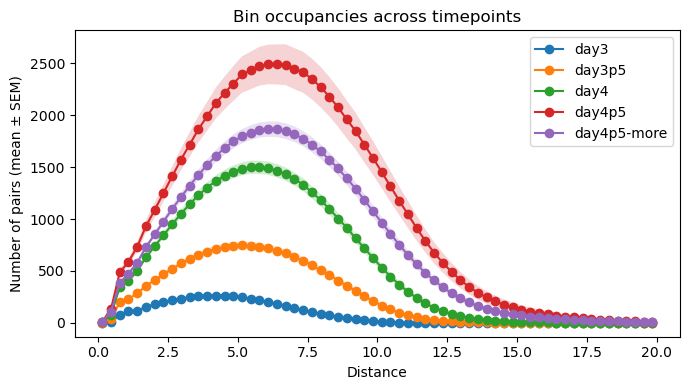

In [22]:
plt.figure(figsize=(7,4))

for tp, res in results.items():
    pair_counts_arr = res['pair_counts_arr']       # (n_org, nbins)
    mean_counts = pair_counts_arr.mean(axis=0)
    std_counts = pair_counts_arr.std(axis=0, ddof=1)
    sem_counts = std_counts / np.sqrt(pair_counts_arr.shape[0])

    # Plot mean ± SEM for this timepoint
    plt.plot(bin_centers, mean_counts, 'o-', label=f'{tp}')
    plt.fill_between(bin_centers,
                     mean_counts - sem_counts,
                     mean_counts + sem_counts,
                     alpha=0.2)

plt.xlabel("Distance")
plt.ylabel("Number of pairs (mean ± SEM)")
plt.title("Bin occupancies across timepoints")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_1892808/990496366.py:6: RuntimeWarning: Mean of empty slice
  mean_C = np.nanmean(res["Corr_all"], axis=0)   # (B,F,F)
/tmp/ipykernel_1892808/990496366.py:16: RuntimeWarning: Mean of empty slice
  mean_C = np.nanmean(res["Corr_conn_all"], axis=0)   # (B,F,F)
/tmp/ipykernel_1892808/990496366.py:25: RuntimeWarning: Mean of empty slice
  mean_C = np.nanmean(res["Corr_norm_all"], axis=0)   # (B,F,F)


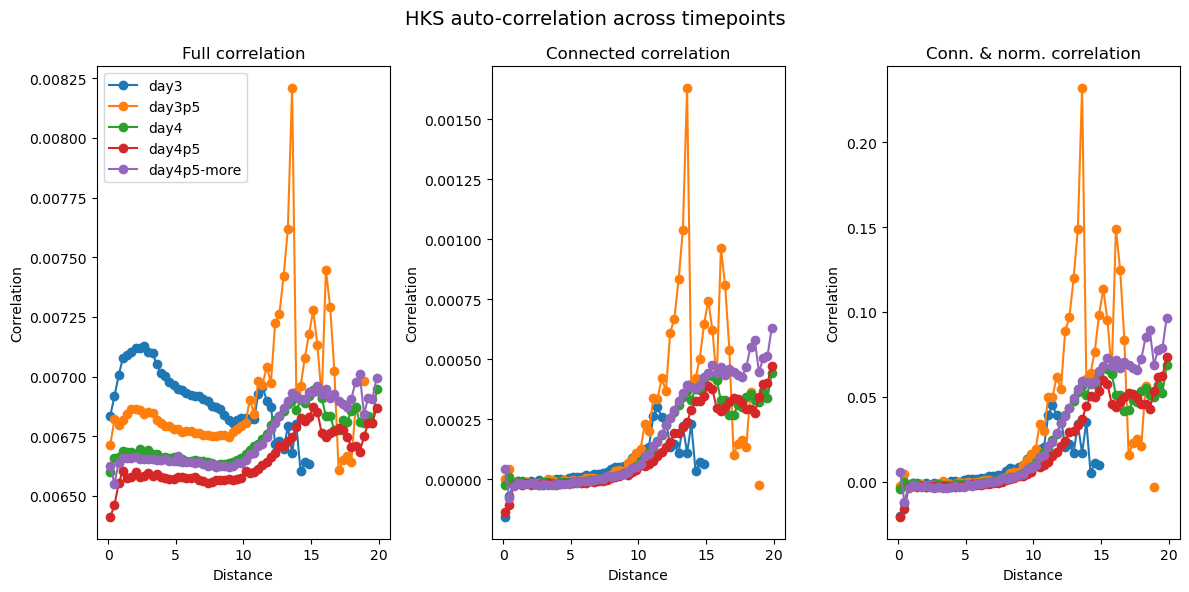

In [23]:

plt.figure(figsize=(12,6))

# --- Full correlation ---
plt.subplot(1,3,1)
for tp, res in results.items():
    mean_C = np.nanmean(res["Corr_all"], axis=0)   # (B,F,F)
    plt.plot(bin_centers, mean_C[:,0,0], 'o-', label=tp)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Full correlation")
plt.legend()

# --- Connected correlation ---
plt.subplot(1,3,2)
for tp, res in results.items():
    mean_C = np.nanmean(res["Corr_conn_all"], axis=0)   # (B,F,F)
    plt.plot(bin_centers, mean_C[:,0,0], 'o-', label=tp)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Connected correlation")

# --- Connected + normalized correlation ---
plt.subplot(1,3,3)
for tp, res in results.items():
    mean_C = np.nanmean(res["Corr_norm_all"], axis=0)   # (B,F,F)
    plt.plot(bin_centers, mean_C[:,0,0], 'o-', label=tp)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Conn. & norm. correlation")

plt.suptitle("HKS auto-correlation across timepoints", fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1892808/3130485620.py:20: RuntimeWarning: Mean of empty slice
  mean_corr = np.nanmean(res["Corr_conn_all"][:,:,i,j], axis=0)  # (B,)


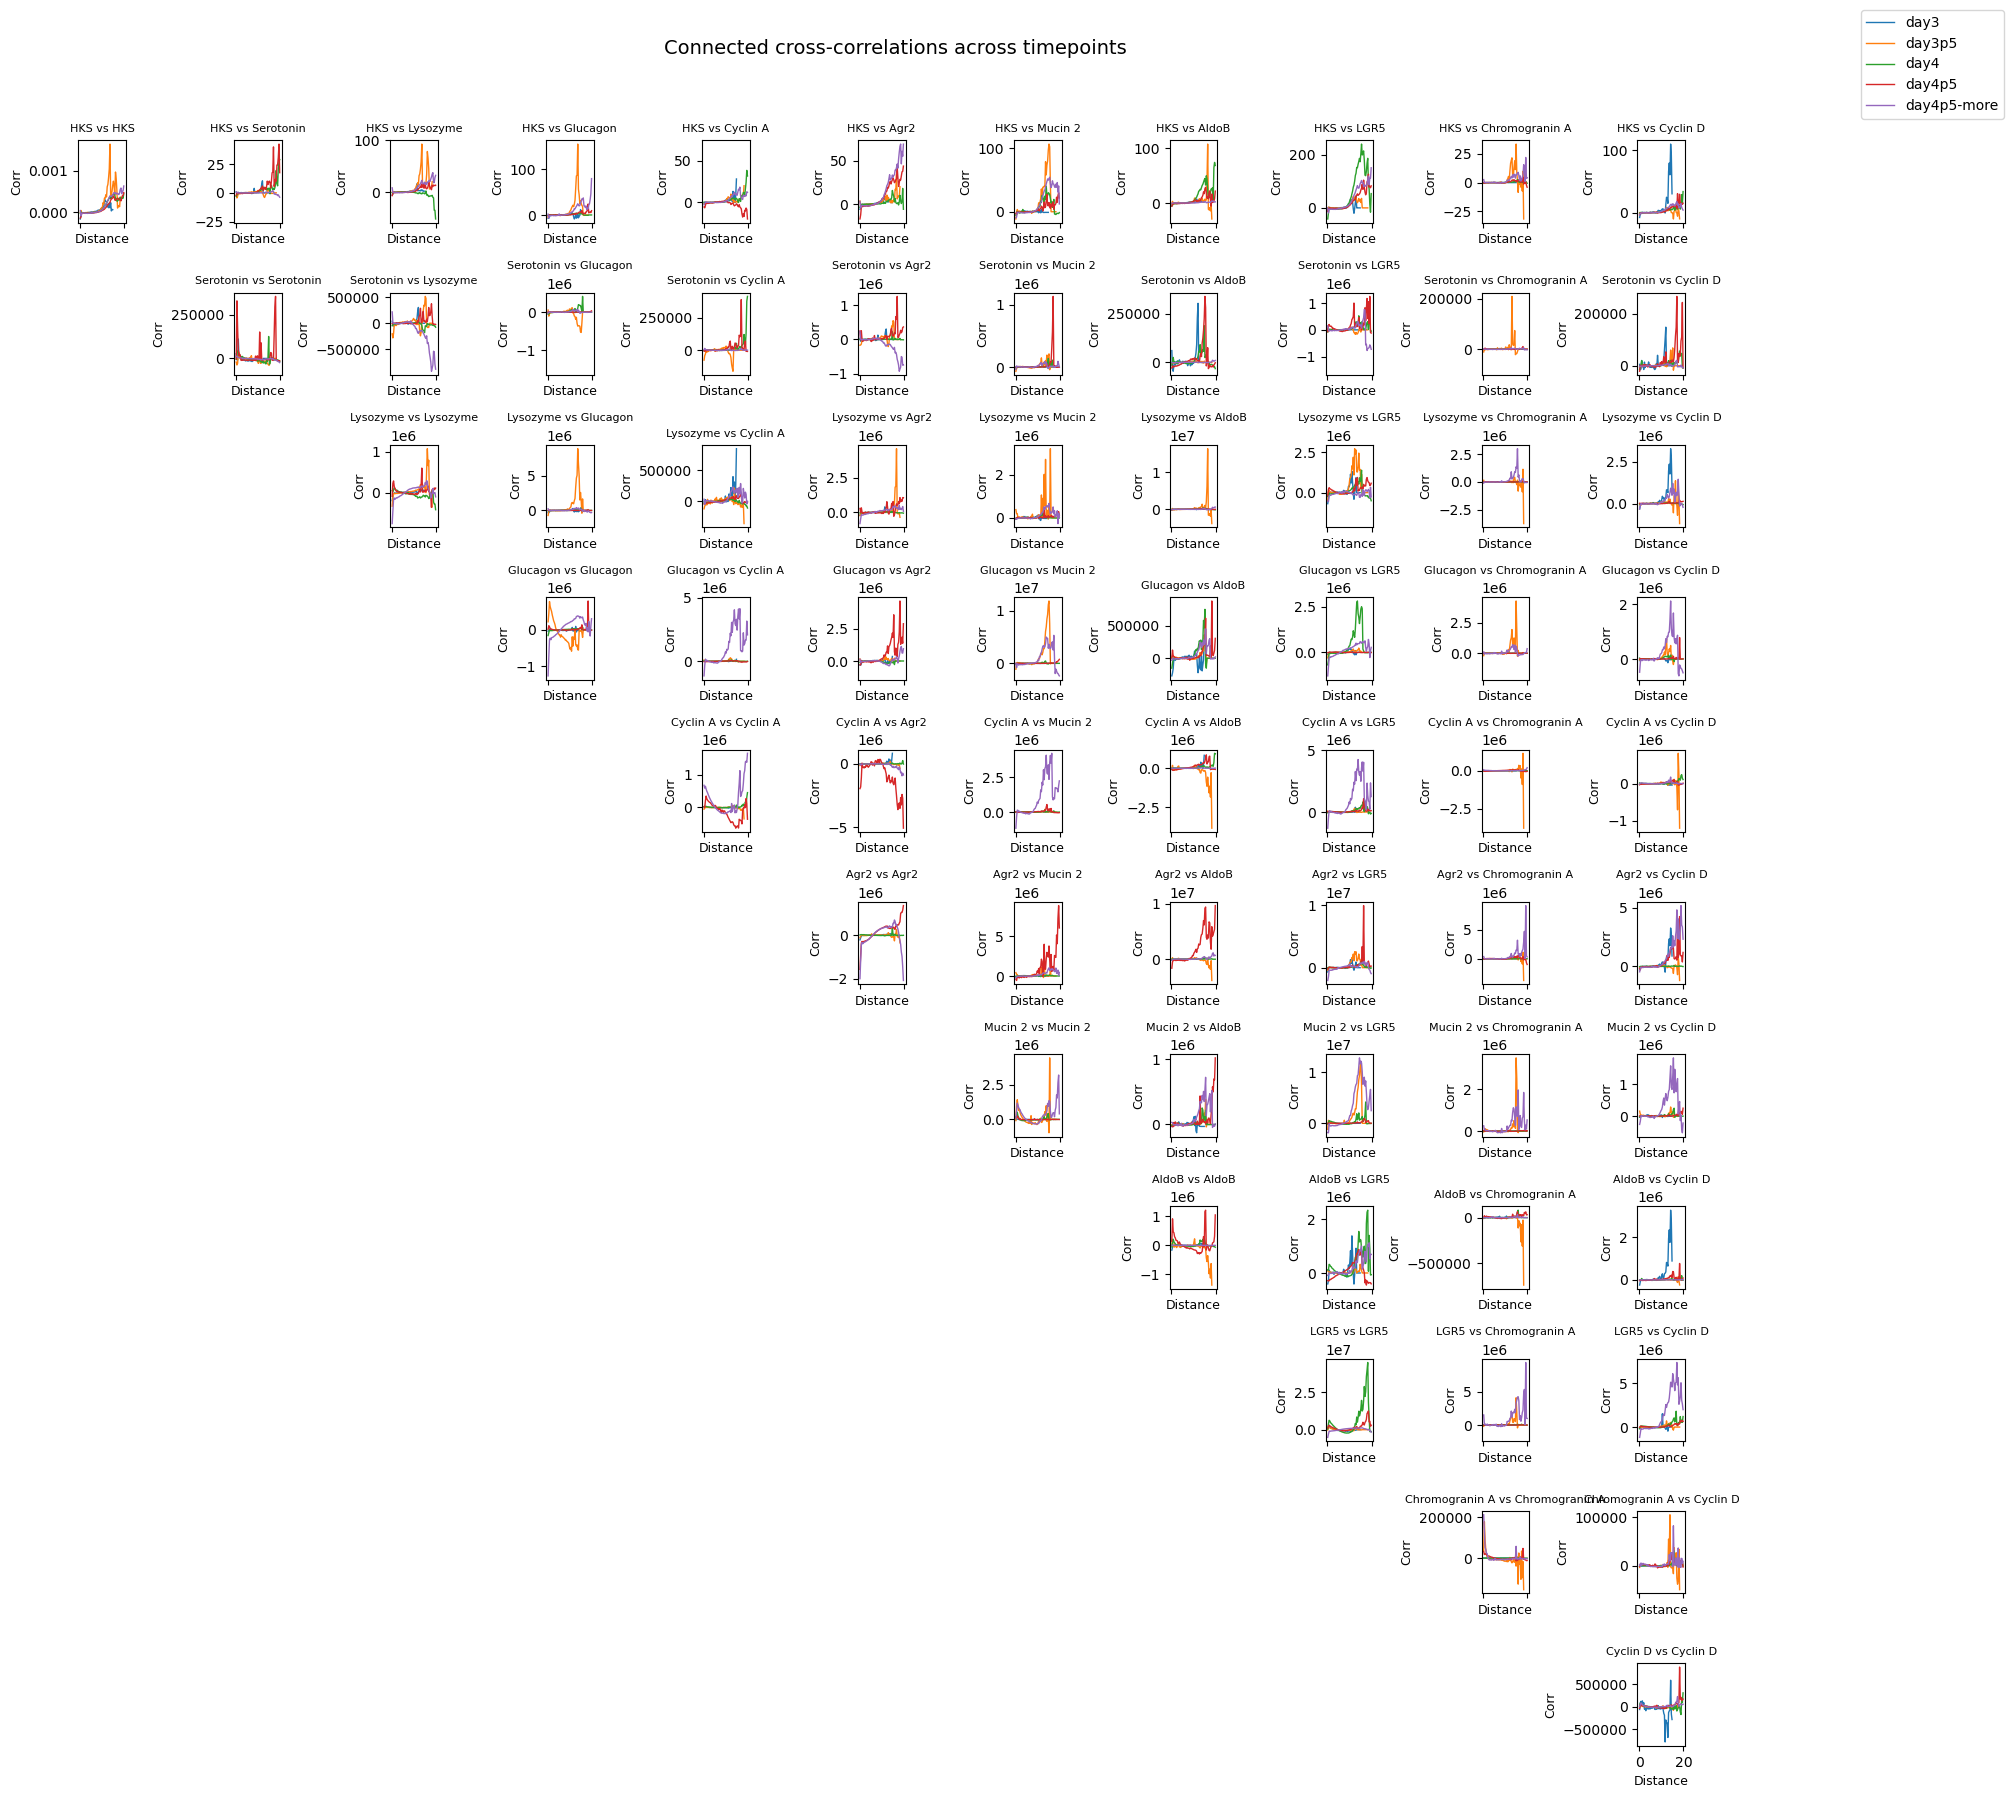

In [41]:

# Grab field dimension info from one timepoint
sample_tp = next(iter(results))
_, B, F, _ = results[sample_tp]["Corr_conn_all"].shape

field_names = ["HKS", "Serotonin", "Lysozyme", "Glucagon", "Cyclin A", "Agr2", "Mucin 2",
            "AldoB", "LGR5", "Chromogranin A", "Cyclin D"]

fig, axes = plt.subplots(F, F, figsize=(18, 18), sharex=True, sharey=False)

for i in range(F):
    for j in range(F):
        ax = axes[i, j]

        if i > j:
            ax.axis("off")  # hide lower triangle
            continue

        # Loop over timepoints
        for tp, res in results.items():
            mean_corr = np.nanmean(res["Corr_conn_all"][:,:,i,j], axis=0)  # (B,)
            ax.plot(bin_centers, mean_corr, lw=1, label=tp if (i==0 and j==0) else "")

        ax.set_title(f"{field_names[i]} vs {field_names[j]}", fontsize=8)
        ax.set_ylabel("Corr", fontsize=9)
        ax.set_xlabel("Distance", fontsize=9)

# Global labels + legend
fig.suptitle("Connected cross-correlations across timepoints", fontsize=14)
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.12, 1.0))
plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()

## Group organoids

If the organoids do not develop any protrusions, i.e. they are sphere-like, they will likely show different correlation behavior. Hence it may be worth exploring whether we need to calculate correlations across groups, rather than days. 

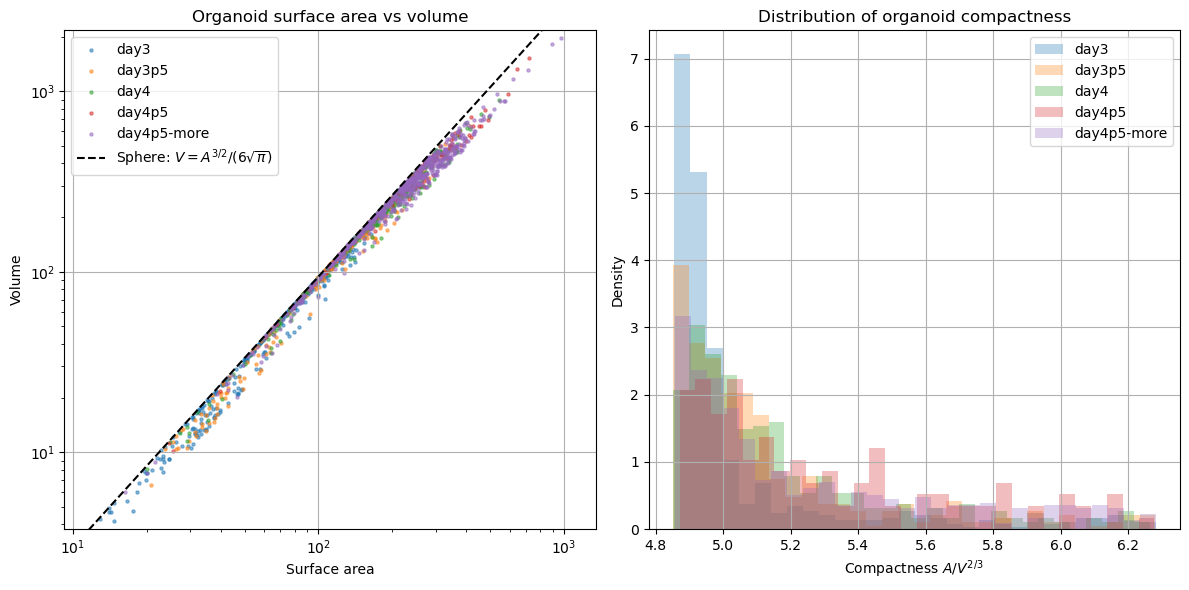

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# --- Left: scatter area vs volume ---
ax = axes[0]
for tp, res in results.items():
    tot_area_all = res["tot_area"]
    tot_volume_all = res["tot_volume"]
    ax.scatter(tot_area_all, tot_volume_all, s=5, alpha=0.5, label=tp)

# Reference curve: sphere relation
all_area = np.concatenate([res["tot_area"] for res in results.values()])
all_volume = np.concatenate([res["tot_volume"] for res in results.values()])

A_range = np.linspace(all_area.min()*0.9, all_area.max()*1.1, 200)
V_sphere = (1.0 / (6.0 * np.sqrt(np.pi))) * (A_range**1.5)

ax.plot(A_range, V_sphere, 'k--', label=r"Sphere: $V = A^{3/2} / (6\sqrt{\pi})$")

ax.set_xlabel("Surface area")
ax.set_ylabel("Volume")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Organoid surface area vs volume")
ax.legend()
ax.grid(True)
ax.set_ylim(all_volume.min()*0.9, all_volume.max()*1.1)

# --- Right: histogram of compactness ---
ax = axes[1]
for tp, res in results.items():
    compactness = res["tot_area"] / (res["tot_volume"] ** (2/3))
    ax.hist(compactness, bins=30, alpha=0.3, label=tp, density=True)

ax.set_xlabel(r"Compactness $A / V^{2/3}$")
ax.set_ylabel("Density")
ax.set_title("Distribution of organoid compactness")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

476
134


/tmp/ipykernel_1892808/3701582500.py:21: RuntimeWarning: Mean of empty slice
  Corr_sphere = np.nanmean(res["Corr_conn_all"][group_sphere_like], axis=0)  # (B,F,F)
/tmp/ipykernel_1892808/3701582500.py:26: RuntimeWarning: Mean of empty slice
  Corr_protruded = np.nanmean(res["Corr_conn_all"][group_protruded], axis=0)  # (B,F,F)


240
155
214
186
51
73
326
331


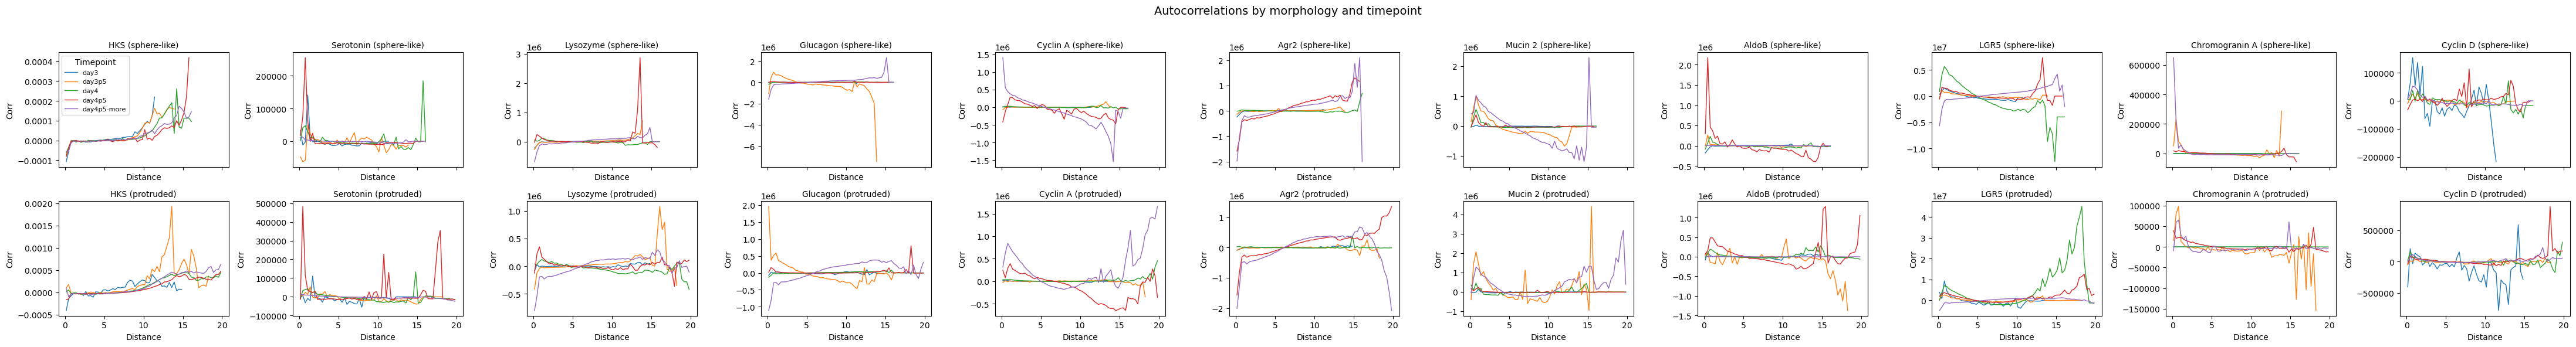

In [43]:
comp_sphere = 4.835
threshold = 1.05 * comp_sphere   # 20% larger than sphere

F = len(field_names)

fig, axes = plt.subplots(2, F, figsize=(4*F, 6), sharex=True)

for tp, res in results.items():
    tot_area = res["tot_area"]
    tot_volume = res["tot_volume"]
    compactness = tot_area / (tot_volume ** (2/3))

    group_sphere_like = (compactness <= threshold) 
    group_protruded   = (compactness > threshold) 

    print(np.sum(group_sphere_like))
    print(np.sum(group_protruded))


    if np.any(group_sphere_like):
        Corr_sphere = np.nanmean(res["Corr_conn_all"][group_sphere_like], axis=0)  # (B,F,F)
        for f in range(F):
            axes[0, f].plot(bin_centers, Corr_sphere[:, f, f], '-', lw=1, label=tp)

    if np.any(group_protruded):
        Corr_protruded = np.nanmean(res["Corr_conn_all"][group_protruded], axis=0)  # (B,F,F)
        for f in range(F):
            axes[1, f].plot(bin_centers, Corr_protruded[:, f, f], '-', lw=1, label=tp)

# Row/col titles
for f in range(F):
    axes[0, f].set_title(f"{field_names[f]} (sphere-like)", fontsize=10)
    axes[1, f].set_title(f"{field_names[f]} (protruded)", fontsize=10)
    for r in range(2):
        axes[r, f].set_xlabel("Distance")
        axes[r, f].set_ylabel("Corr")

# Legends
axes[0, 0].legend(title="Timepoint", fontsize=8)

fig.suptitle("Autocorrelations by morphology and timepoint", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [44]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.manifold import MDS
from sklearn.cluster import KMeans


def cluster_correlations(C_all, threshold = 0.8, k=2):

    # C_all: (n_org, B) correlation curves (NaNs at long distances)
    n_org, B = C_all.shape

    # 1) compute coverage per bin
    valid_counts = np.sum(~np.isnan(C_all), axis=0)   # shape (B,)
    frac = valid_counts / n_org

    # 2) choose bins where fraction >= threshold
    mask_bins = frac >= threshold
    print("Using", mask_bins.sum(), "bins out of", B)

    # 3) build feature matrix truncated
    X = C_all[:, mask_bins]

    # 4) for each organoid, if there are still NaNs inside truncated region (rare), impute with linear interp or fill with bin mean
    for i in range(n_org):
        row = X[i]
        if np.isnan(row).any():
            # linear interp across available points
            good = ~np.isnan(row)
            if good.sum() >= 2:
                xp = np.where(good)[0]
                fp = row[good]
                x = np.arange(len(row))
                X[i] = np.interp(x, xp, fp)
            else:
                # fallback: fill with zeros
                X[i] = np.nan_to_num(row, nan=0.0)

    # 5) standardize per-sample (z-score) or globally. Here per-sample:
    # Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, ddof=1, keepdims=True) + 1e-12)
    Xz = (X ) / (X.std(axis=1, ddof=1, keepdims=True) + 1e-12)
    # Xz = (X ) / (X.mean(axis=1, keepdims=True) + 1e-12)
    # Xz = X

    # 6) cluster
    km = KMeans(n_clusters=k, random_state=0).fit(Xz)
    labels = km.labels_

    return km, labels, mask_bins, Xz

Using 39 bins out of 64
Cluster 0: 393 members
Cluster 1: 541 members


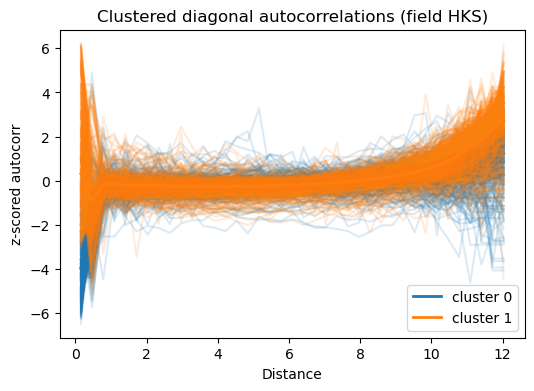

In [53]:
# --- Concatenate diagonal autocorrelations across timepoints ---
vol_min = 200
field_idx = 0  # e.g., HKS diagonal

C_all_list = []
for tp, res in results.items():
    tot_volume = res["tot_volume"]
    C_conn = res["Corr_conn_all"]  # (n_org, B, F, F)
    mask = tot_volume > vol_min
    if np.any(mask):
        C_all_list.append(C_conn[mask, :, field_idx, field_idx])

C_all_cat = np.vstack(C_all_list)  # (N_total, B)

# Run clustering
km, labels, mask_bins, Cz = cluster_correlations(C_all_cat, k=2, threshold=0.8)

# Plot clusters
centroids = km.cluster_centers_
r_plot = bin_centers[mask_bins]
plt.figure(figsize=(6,4))
for c in range(km.n_clusters):
    members = Cz[labels==c]

    print(f"Cluster {c}: {members.shape[0]} members")

    # plot individual curves lightly
    for row in members:
        plt.plot(r_plot, row, color=f"C{c}", alpha=0.15)
    # plot centroid
    plt.plot(r_plot, centroids[c], color=f"C{c}", lw=2, label=f"cluster {c}")

plt.xlabel("Distance")
plt.ylabel("z-scored autocorr")
plt.title(f"Clustered diagonal autocorrelations (field {field_names[field_idx]})")
plt.legend()
plt.show()

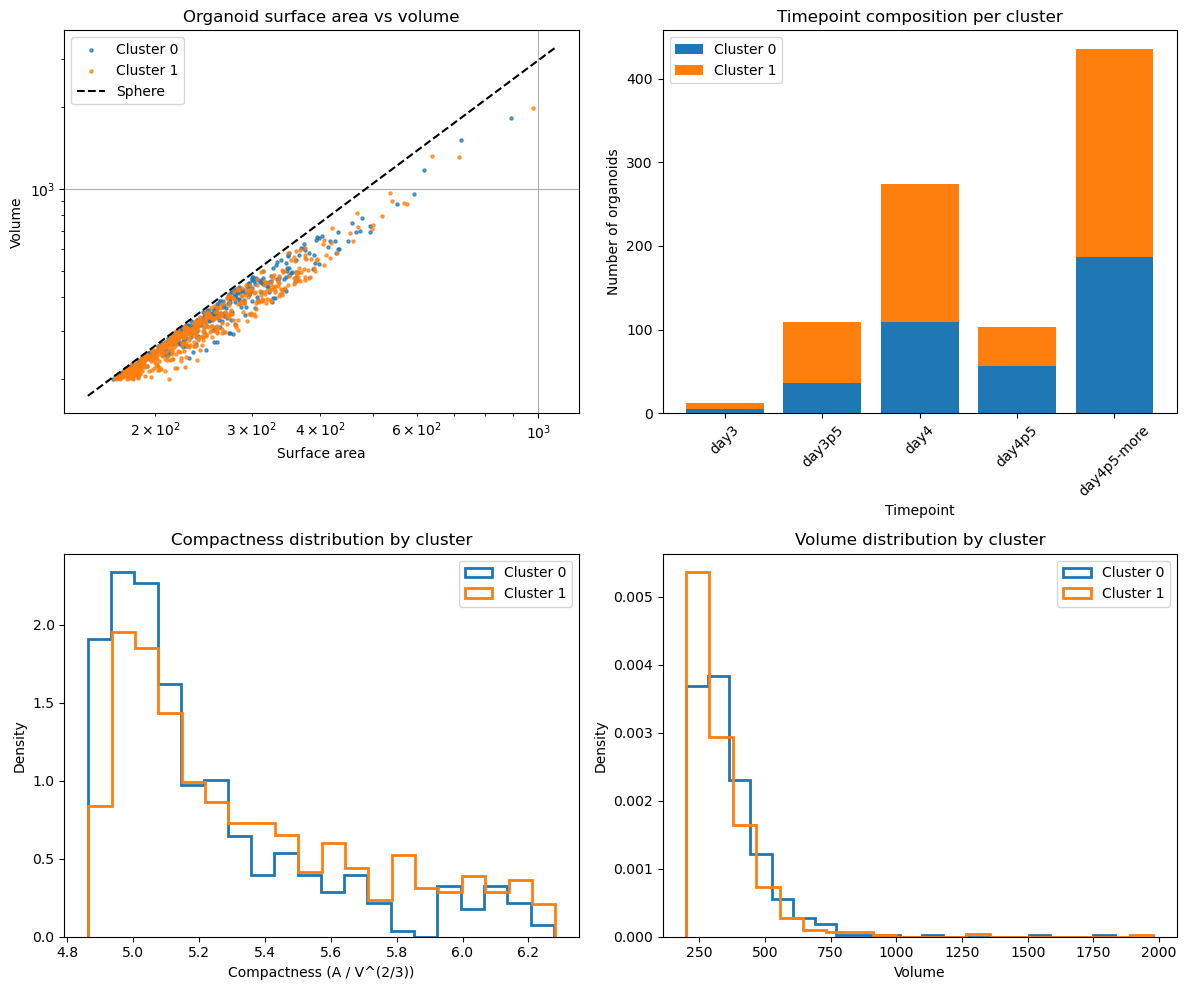

In [54]:
tot_area_list = []
tot_volume_list = []
timepoint_indices = []   # keep track of global indices per timepoint

start = 0
for tp, res in results.items():
    tot_volume = res["tot_volume"]
    mask = tot_volume > vol_min
    n_org = np.sum(mask)
    if n_org > 0:
        tot_area_list.append(res["tot_area"][mask])
        tot_volume_list.append(tot_volume[mask])

        # store global indices for this timepoint
        idx_global = np.arange(start, start + n_org)
        timepoint_indices.append(idx_global)

        start += n_org

tot_area_cat = np.concatenate(tot_area_list)
tot_volume_cat = np.concatenate(tot_volume_list)

# --- compute compactness ---
compactness_cat = tot_area_cat / (tot_volume_cat ** (2/3))

# --- figure setup ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# 1) Scatter plot of area vs volume colored by cluster
for c in range(km.n_clusters):
    axes[0].scatter(
        tot_area_cat[labels == c], tot_volume_cat[labels == c],
        alpha=0.7, label=f"Cluster {c}", s=5
    )
A_range = np.linspace(tot_area_cat.min()*0.9, tot_area_cat.max()*1.1, 200)
V_sphere = (1.0 / (6.0 * np.sqrt(np.pi))) * (A_range**1.5)
axes[0].plot(A_range, V_sphere, 'k--', label=r"Sphere")
axes[0].set_yscale("log")
axes[0].set_xscale("log")
axes[0].set_xlabel("Surface area")
axes[0].set_ylabel("Volume")
axes[0].set_title("Organoid surface area vs volume")
axes[0].legend()
axes[0].grid(True)

# 2) Timepoint composition within each cluster (stacked bar)
timepoints_list = list(results.keys())
cluster_counts = np.zeros((len(timepoints_list), km.n_clusters), dtype=int)

for i, idx_global in enumerate(timepoint_indices):
    tp_labels = labels[idx_global]   # correct global labels for this timepoint
    for c in range(km.n_clusters):
        cluster_counts[i, c] = np.sum(tp_labels == c)

bottom = np.zeros(len(timepoints_list), dtype=int)
colors = plt.cm.tab10.colors[:km.n_clusters]
for c in range(km.n_clusters):
    axes[1].bar(timepoints_list, cluster_counts[:, c], bottom=bottom,
                color=colors[c], label=f"Cluster {c}")
    bottom += cluster_counts[:, c]

axes[1].set_xlabel("Timepoint")
axes[1].set_ylabel("Number of organoids")
axes[1].set_title("Timepoint composition per cluster")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# 3) Histogram of compactness per cluster
for c in range(km.n_clusters):
    axes[2].hist(
        compactness_cat[labels == c], bins=20,
        density=True, histtype='step', lw=2, label=f"Cluster {c}"
    )
axes[2].set_xlabel("Compactness (A / V^(2/3))")
axes[2].set_ylabel("Density")
axes[2].set_title("Compactness distribution by cluster")
axes[2].legend()

# 4) Histogram of volume per cluster
for c in range(km.n_clusters):
    axes[3].hist(
        tot_volume_cat[labels == c], bins=20,
        density=True, histtype='step', lw=2, label=f"Cluster {c}"
    )
axes[3].set_xlabel("Volume")
axes[3].set_ylabel("Density")
axes[3].set_title("Volume distribution by cluster")
axes[3].legend()

plt.tight_layout()
plt.show()


/tmp/ipykernel_1892808/2658136523.py:43: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 0.95, 0.96])


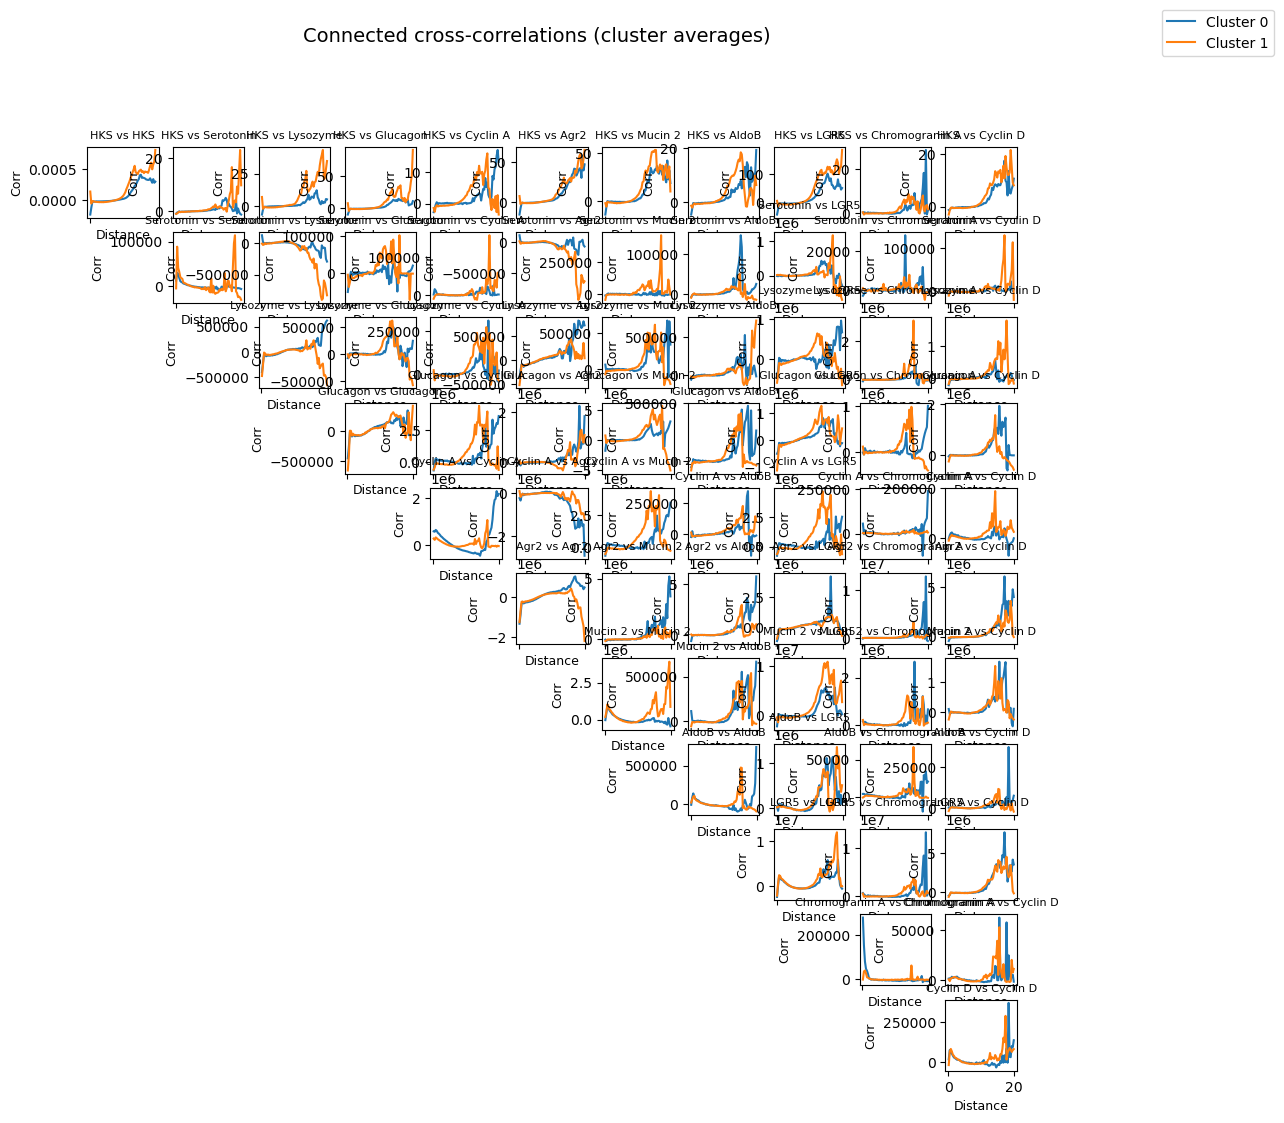

In [55]:
# --- Concatenate clustered organoids from all timepoints ---
all_corr_list = []
for tp, res in results.items():
    corr_tp = res["Corr_conn_all"]    # shape (n_org, B, F, F)
    vol_tp = res["tot_volume"]        # shape (n_org,)
    mask = vol_tp > vol_min           # only organoids used for clustering
    all_corr_list.append(corr_tp[mask])

all_corr_clustered = np.concatenate(all_corr_list, axis=0)  # shape (n_clustered_orgs, B, F, F)

# --- Prepare plotting ---
n_clusters = km.n_clusters
_, B, F, _ = all_corr_clustered.shape
colors = plt.cm.tab10.colors[:km.n_clusters]

fig, axes = plt.subplots(F, F, figsize=(12, 12), sharex=True, sharey=False)

for i in range(F):
    for j in range(F):
        ax = axes[i, j]

        if i > j:
            ax.axis("off")
            continue

        # Loop over clusters
        for c in range(n_clusters):
            cluster_mask = labels == c
            if np.sum(cluster_mask) == 0:
                continue
            mean_corr = np.nanmean(all_corr_clustered[cluster_mask, :, i, j], axis=0)  # (B,)
            ax.plot(bin_centers, mean_corr, lw=1.5, color=colors[c],
                    label=f"Cluster {c}" if (i==0 and j==0) else "")

        ax.set_title(f"{field_names[i]} vs {field_names[j]}", fontsize=8)
        ax.set_ylabel("Corr", fontsize=9)
        ax.set_xlabel("Distance", fontsize=9)

# Global labels + legend
fig.suptitle("Connected cross-correlations (cluster averages)", fontsize=14)
handles, labels_ = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="upper right", bbox_to_anchor=(1.12, 1.0))
plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()


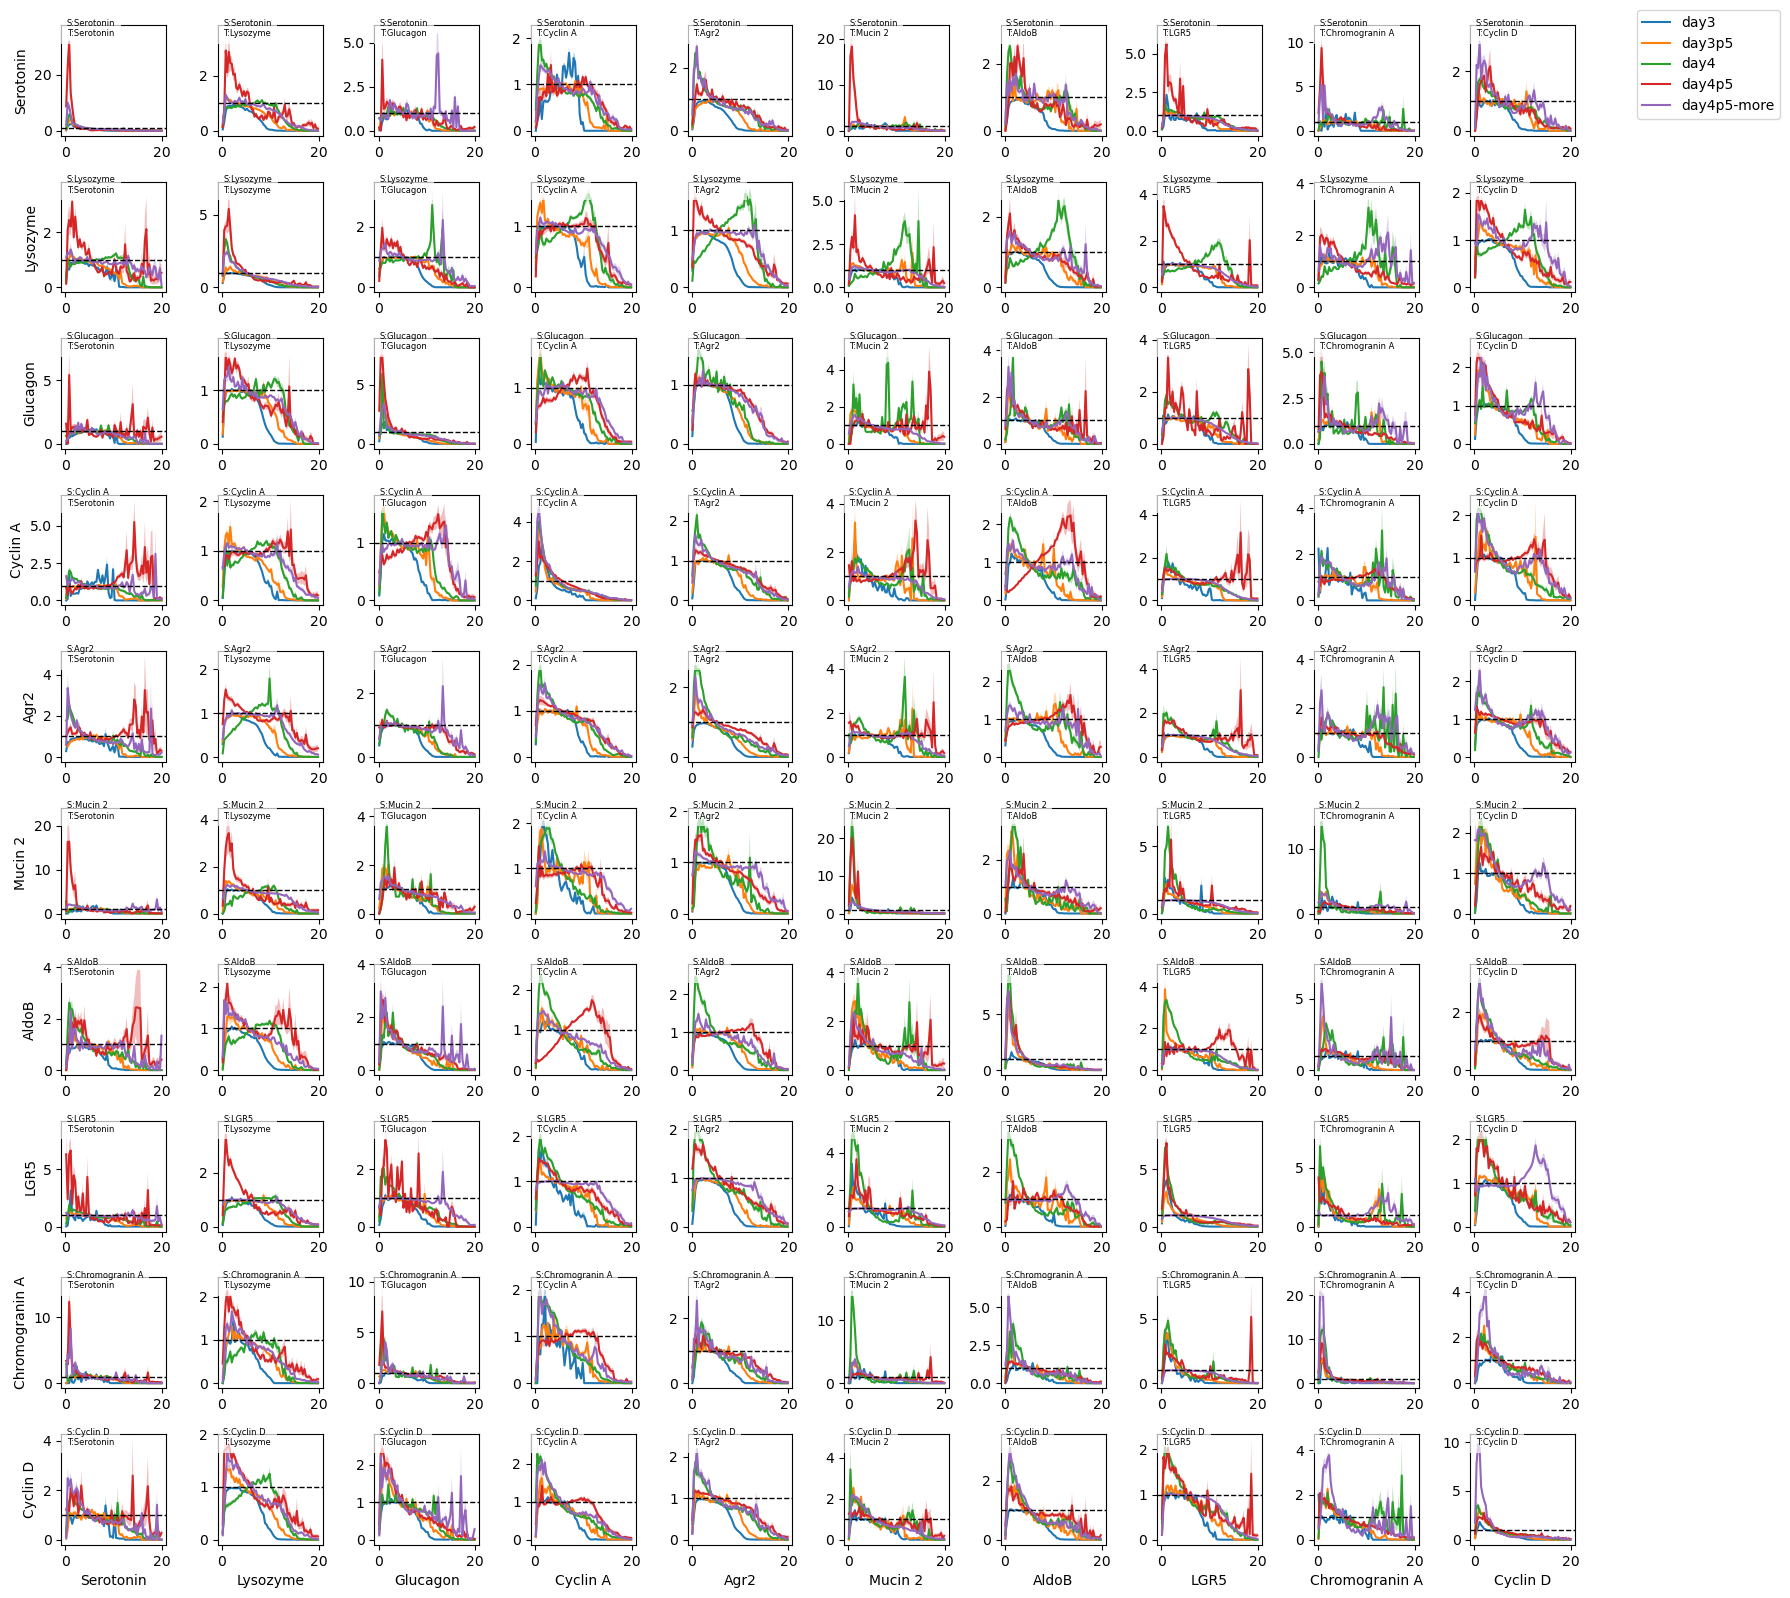

In [64]:
sample_tp = next(iter(results))
_, n_markers, nbins, _ = results[sample_tp]["Enrichment_all"].shape


field_names_subset = field_names[1:]
n_plot_markers = n_markers-1

# -------------------- Plot cross-enrichment grid --------------------
fig, axes = plt.subplots(n_plot_markers, n_plot_markers,
                         figsize=(16, 16),
                         sharex=False, sharey=False)

for i_source in range(n_plot_markers):
    for j_target in range(n_plot_markers):
        ax = axes[i_source, j_target]

        # Plot ensemble-averaged enrichment for each timepoint
        for tp, res in results.items():
            n_organoids = res["Enrichment_all"].shape[0]
            Enrichment_mean = np.nanmean(res["Enrichment_all"][:,i_source+1,:,j_target+1], axis=0)  
            Enrichment_std  = np.nanstd(res["Enrichment_all"][:,i_source+1,:,j_target+1], axis=0)
            Enrichment_sem  = Enrichment_std / np.sqrt(n_organoids)

            ax.plot(bin_centers, Enrichment_mean, label=tp)
            ax.fill_between(bin_centers,
                            Enrichment_mean - Enrichment_sem,
                            Enrichment_mean + Enrichment_sem,
                            alpha=0.3)

        ax.axhline(1.0, color='k', linestyle='--', linewidth=1)

        # Axis labels
        if i_source == n_plot_markers - 1:
            ax.set_xlabel(f"{field_names_subset[j_target]}", fontsize=10)
        if j_target == 0:
            ax.set_ylabel(f"{field_names_subset[i_source]}", fontsize=10)

        ax.tick_params(axis='both', which='major', labelsize=10)

        # Add label inside subplot for quick identification
        ax.text(0.05, 0.9, f"S:{field_names_subset[i_source]}\nT:{field_names_subset[j_target]}",
                transform=ax.transAxes, fontsize=6, color='black',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.12, 1.0))

plt.tight_layout()




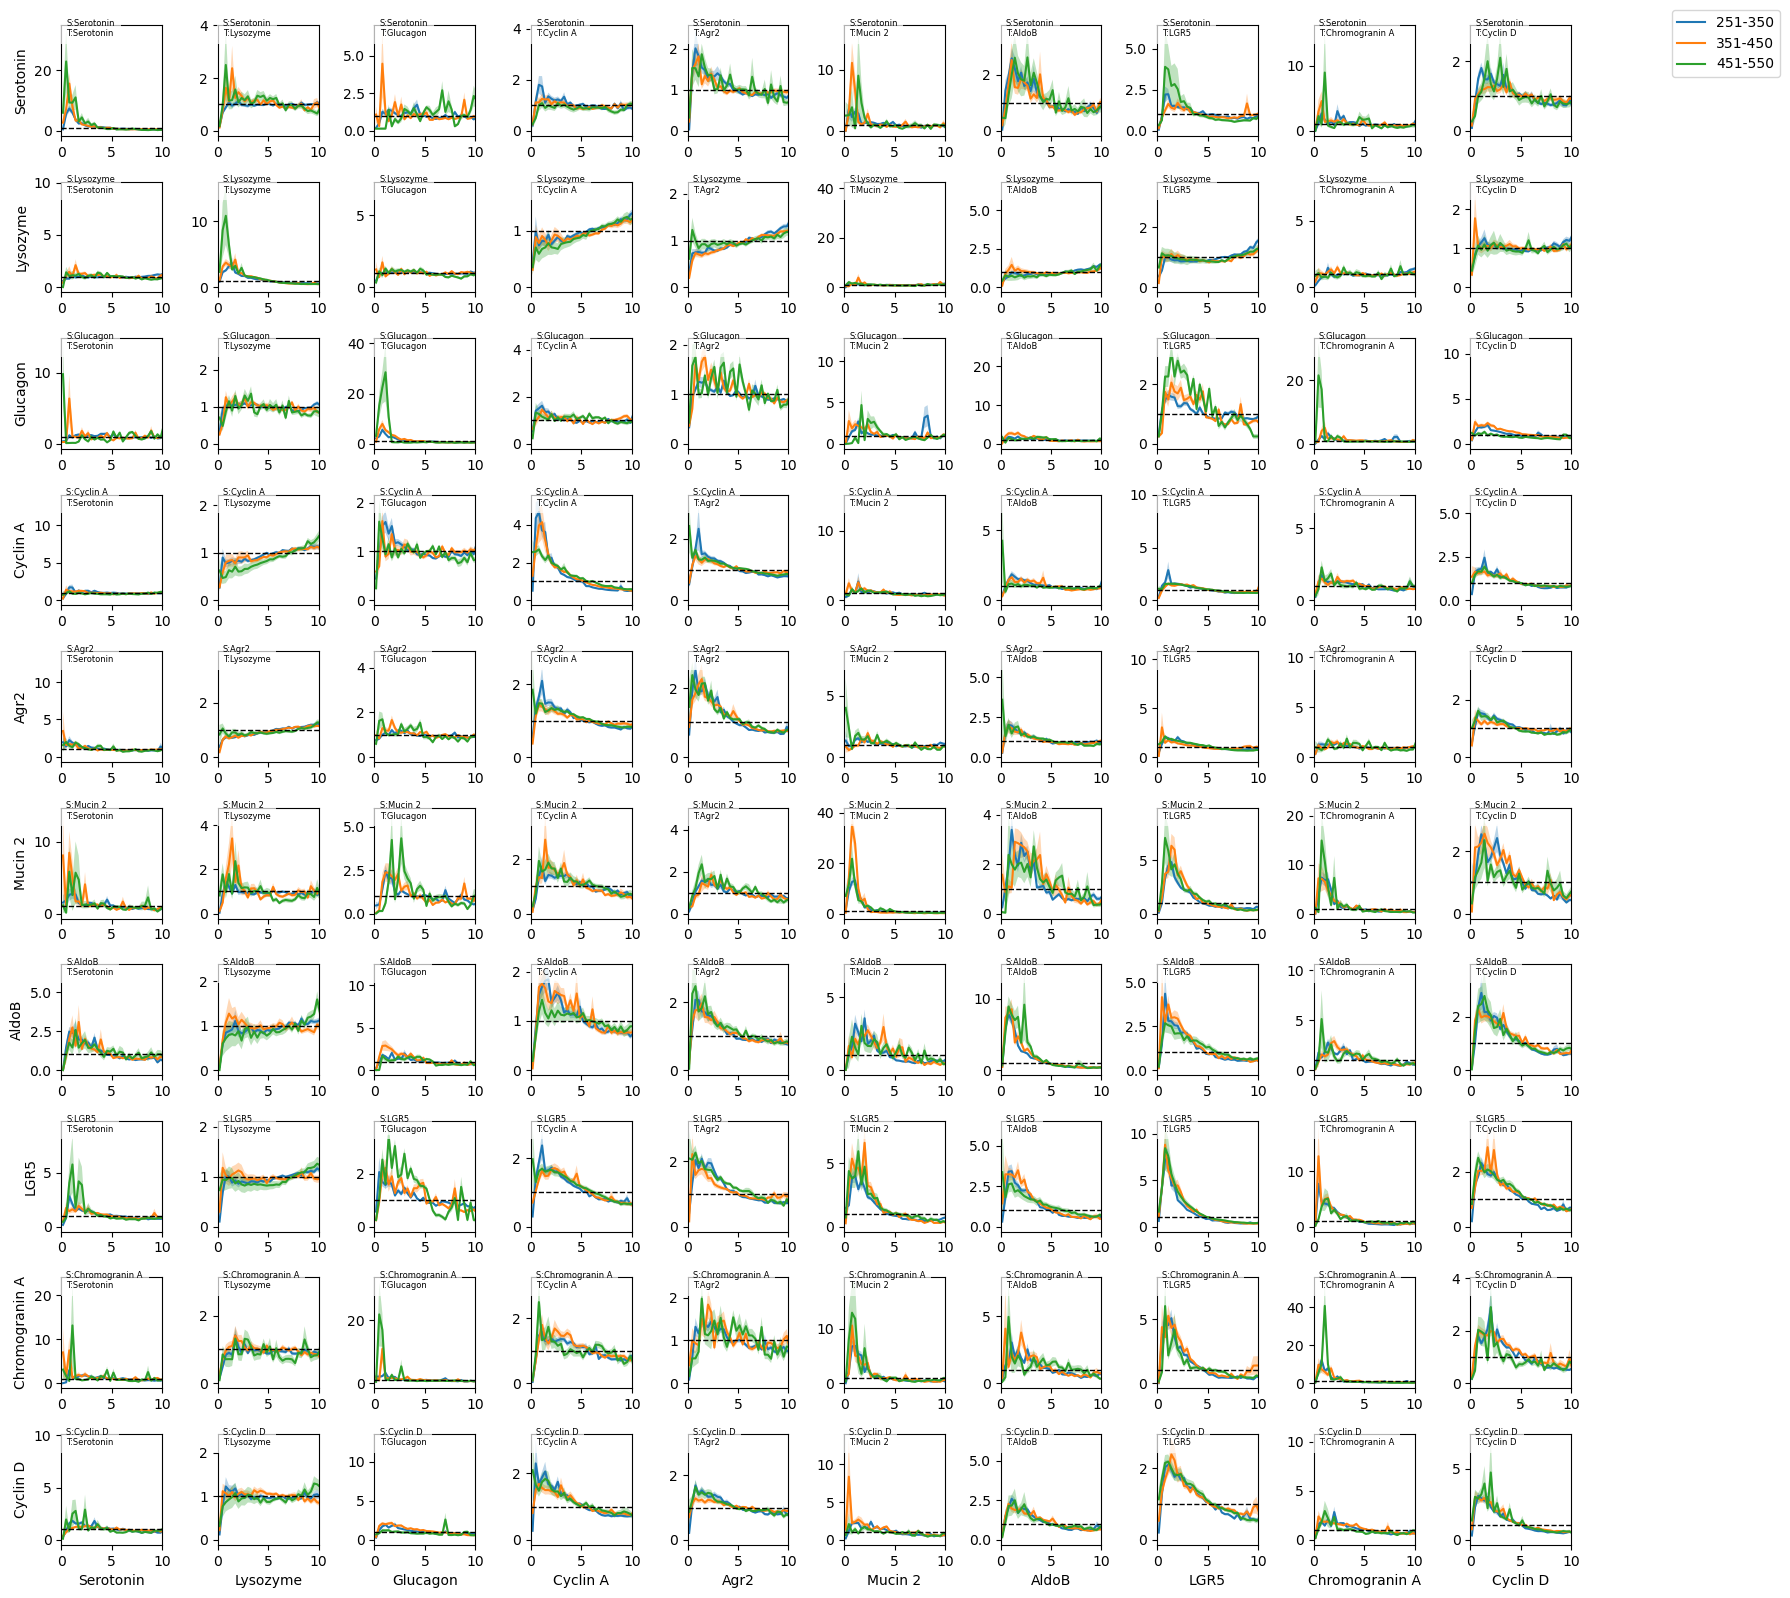

In [ ]:
sample_tp = next(iter(results))
_, n_markers, nbins, _ = results[sample_tp]["Enrichment_all"].shape

field_names_subset = field_names[1:]
n_plot_markers = n_markers - 1

# Define cell count bins
cell_bins = np.arange(250, 551, 100)   # adjust max (1000 here) as needed
bin_labels = [f"{cell_bins[i]+1}-{cell_bins[i+1]}" for i in range(len(cell_bins)-1)]

# -------------------- Plot cross-enrichment grid --------------------
fig, axes = plt.subplots(n_plot_markers, n_plot_markers,
                         figsize=(16, 16),
                         sharex=False, sharey=False)

for i_source in range(n_plot_markers):
    for j_target in range(n_plot_markers):
        ax = axes[i_source, j_target]

        # Loop over cell bins
        for b in range(len(cell_bins)-1):
            bin_min, bin_max = cell_bins[b], cell_bins[b+1]

            # Collect enrichment curves across all timepoints but filtered by num_cells
            curves = []
            for tp, res in results.items():

                mask = (res["num_cell"] > bin_min) & (res["num_cell"] <= bin_max)
                if np.any(mask):
                    curves.append(res["Enrichment_all"][mask, i_source+1, :, j_target+1])

            if len(curves) == 0:
                continue

            curves = np.concatenate(curves, axis=0)  # (n_organoids_in_bin, nbins)

            Enrichment_mean = np.nanmean(curves, axis=0)
            Enrichment_std  = np.nanstd(curves, axis=0)
            Enrichment_sem  = Enrichment_std / np.sqrt(curves.shape[0])

            ax.plot(bin_centers, Enrichment_mean, label=bin_labels[b])
            ax.fill_between(bin_centers,
                            Enrichment_mean - Enrichment_sem,
                            Enrichment_mean + Enrichment_sem,
                            alpha=0.3)

        ax.axhline(1.0, color='k', linestyle='--', linewidth=1)
        ax.set_xlim((0, 10))

        # Axis labels
        if i_source == n_plot_markers - 1:
            ax.set_xlabel(f"{field_names_subset[j_target]}", fontsize=10)
        if j_target == 0:
            ax.set_ylabel(f"{field_names_subset[i_source]}", fontsize=10)

        ax.tick_params(axis='both', which='major', labelsize=10)

        # Add label inside subplot for quick identification
        ax.text(0.05, 0.9, f"S:{field_names_subset[i_source]}\nT:{field_names_subset[j_target]}",
                transform=ax.transAxes, fontsize=6, color='black',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Add one shared legend
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.12, 1.0))

plt.tight_layout()


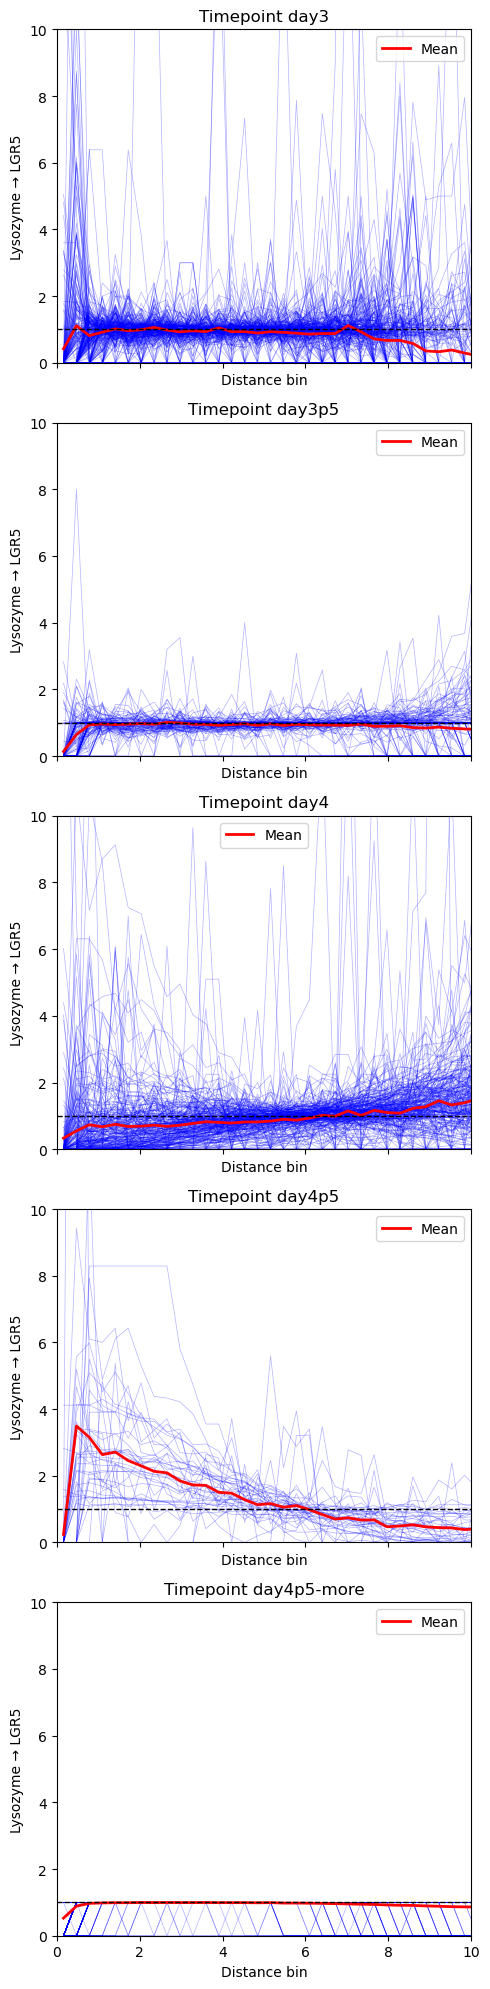

In [84]:
# --- Choose one source and one target ---
i_source = 1   # e.g. index in field_names_subset
j_target = 7   # e.g. index in field_names_subset

# --- Setup plot ---
timepoints = list(results.keys())
n_tps = len(timepoints)

fig, axes = plt.subplots(n_tps, 1, figsize=(5, 4*n_tps), sharex=True)

if n_tps == 1:
    axes = [axes]

for ax, tp in zip(axes, timepoints):
    res = results[tp]

    # Extract enrichment curves: (n_organoids, nbins)
    curves = res["Enrichment_all"][:, i_source+1, :, j_target+1]

    # Plot each organoid curve (thin, transparent)
    for c in curves:
        ax.plot(bin_centers, c, color="blue", linewidth=0.5, alpha=0.3)

    # Compute mean curve
    mean_curve = np.nanmean(curves, axis=0)

    # Plot mean (thicker)
    ax.plot(bin_centers, mean_curve, color="red", linewidth=2, label="Mean")

    # Horizontal line at 1
    ax.axhline(1.0, color="k", linestyle="--", linewidth=1)

    ax.set_xlim((0, 10))
    ax.set_ylim((0, 10))


    ax.set_title(f"Timepoint {tp}")
    ax.set_xlabel("Distance bin")
    ax.set_ylabel(f"{field_names_subset[i_source]} → {field_names_subset[j_target]}")
    ax.legend()

plt.tight_layout()
plt.show()
